# Testing and comparing the models

## 0. Preparation

Importing necessary packages

In [74]:
from scripts.utils import *

In [75]:
import matplotlib.pyplot as plt

In [76]:
from keras.optimizers import Adam

In [77]:
from scripts.GRU import UnidirectionalGRU, BidirectionalGRU
from scripts.BasicLSTM import UnidirectionalLSTM, BidirectionalLSTM
from scripts.AttentionLSTM import UnidirectionalLSTMAttention, BidirectionalLSTMAttention

Running data preparation to get training and testing sets

In [78]:
%run data_preparation.ipynb

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 1 0]
 [0 0 0 ... 0 1 0]
 [1 0 0 ... 0 0 0]] (7702, 14)
['i feel nothing towards this situation'
 "i am beaming with pride for my child's achievements"
 'even though things are tough right now, i still have hope for the future'
 ... 'i regret not pursuing my passion when i had the chance'
 'the regret of not saying goodbye to a loved one haunts me'
 "i'm so angry at the way my boss treated me today."]
[[  0   0   0 ...  63 107  28]
 [  0   0   0 ... 717 216 122]
 [  0   0   0 ...  11   1  69]
 ...
 [  0   0   0 ...   1  51 157]
 [  0   0   0 ...  14 907   6]
 [  0   0   0 ...   6 185   4]]
(6161, 30) (1541, 30)
(6161, 14) (1541, 14)


Testing results of data preparation by printing the shapes of prepared subsets

In [42]:
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(6161, 30) (1541, 30)
(6161, 14) (1541, 14)


## 1. Unidirectional GRU model without Attention

### 1.1 Building and training

Instantiating the model

In [43]:
modelGRU1 = UnidirectionalGRU
modelGRU1.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_4 (Embedding)     (None, 30, 64)            192000    
                                                                 
 gru (GRU)                   (None, 30, 32)            9408      
                                                                 
 dropout_10 (Dropout)        (None, 30, 32)            0         
                                                                 
 batch_normalization_8 (Batc  (None, 30, 32)           128       
 hNormalization)                                                 
                                                                 
 gru_1 (GRU)                 (None, 16)                2400      
                                                                 
 dropout_11 (Dropout)        (None, 16)                0         
                                                      

Compiling the model

In [44]:
modelGRU1.compile(loss=['categorical_crossentropy'], metrics=['accuracy'], optimizer=Adam(0.0001))

Training the model

In [46]:
historyGRU1 = modelGRU1.fit(x_train, y_train, batch_size=32, epochs=30, validation_split=0.2)

Epoch 1/30
154/154 [==============================] - 4s 27ms/step - loss: 1.6946 - accuracy: 0.4927 - val_loss: 1.4451 - val_accuracy: 0.7007
Epoch 2/30
154/154 [==============================] - 4s 24ms/step - loss: 1.5985 - accuracy: 0.5325 - val_loss: 1.3676 - val_accuracy: 0.7170
Epoch 3/30
154/154 [==============================] - 4s 28ms/step - loss: 1.5512 - accuracy: 0.5558 - val_loss: 1.2916 - val_accuracy: 0.7567
Epoch 4/30
154/154 [==============================] - 4s 29ms/step - loss: 1.4772 - accuracy: 0.5816 - val_loss: 1.2249 - val_accuracy: 0.7859
Epoch 5/30
154/154 [==============================] - 5s 30ms/step - loss: 1.4107 - accuracy: 0.6287 - val_loss: 1.1652 - val_accuracy: 0.7981
Epoch 6/30
154/154 [==============================] - 5s 30ms/step - loss: 1.3514 - accuracy: 0.6439 - val_loss: 1.0963 - val_accuracy: 0.8224
Epoch 7/30
154/154 [==============================] - 5s 30ms/step - loss: 1.2852 - accuracy: 0.6646 - val_loss: 1.0519 - val_accuracy: 0.8345

### 1.2 Visualizing model results and training history

Summarizing history for loss

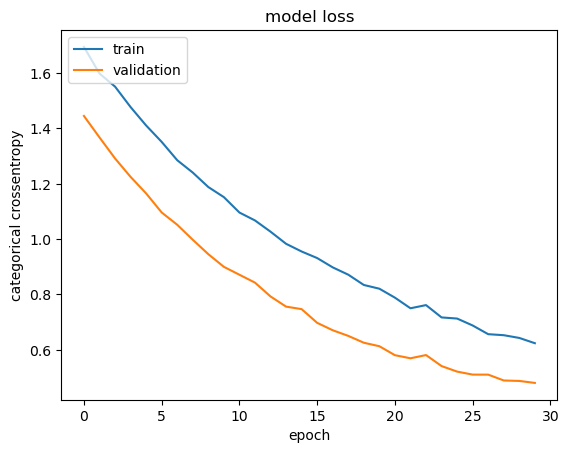

In [49]:
plt.plot(historyGRU1.history['loss'])
plt.plot(historyGRU1.history['val_loss'])
plt.title('model loss')
plt.ylabel('categorical crossentropy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Summarizing history for accuracy

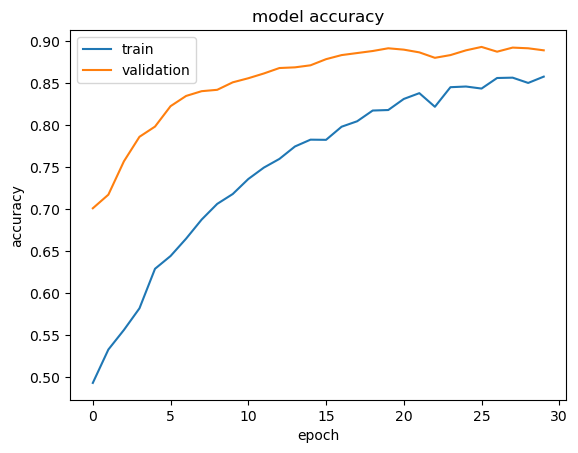

In [50]:
plt.plot(historyGRU1.history['accuracy'])
plt.plot(historyGRU1.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

### 1.3 Testing the model

##### Evaluating the model

In [51]:
loss, accuracy = modelGRU1.evaluate(x_test, y_test)
print(f'loss: {loss}')
print(f'accuracy:{accuracy}')

49/49 [==============================] - 1s 11ms/step - loss: 0.5234 - accuracy: 0.8787
loss: 0.5234012007713318
accuracy:0.8786502480506897


*The accuracy is about 90%*

##### Testing on examples

In [79]:
result = test_on_examples(modelGRU1, tokenizer)

NameError: name 'TEST_EXAMPLES' is not defined